<a href="https://colab.research.google.com/github/Ar7urF1gueired0/calculo_numerico/blob/main/Atividade_I_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade I - Cálculo Numérico: Conteitos fundamentais

### Environment Setup
Nesta célula vamos importar todas as ferramentas do Python necessárias para realizarmos nossos cálculos.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot') # <- Melhora a estética dos nossos gráficos

### Definição de funções básicas

In [ ]:
def truncar(x, n):
  fator = 10**n
  return math.trunc(x * fator)/fator

def erro_abs(x, x_apr):
  return abs(x - x_apr)

def erro_rel(x, x_apr):
  return abs(x - x_apr)/abs(x)

def erro_pct(x, x_apr):
  return erro_rel(x, x_apr)*100


## Parte A - Na próxima seção vamos resolver o primeiro problema

Consideremos: <br>
x1 = 3,14159265 <br>
x2 = 98,76543 <br>
x3 = 0,00498765. <br>

In [ ]:
valores_x = [3.14159265, 98.76543, 0.00498765]
nomes_x = ['x1', 'x2', 'x3']
n_casas = [0, 1, 2, 3, 4]

Organizemos os resultados das aproximações, truncamentos e erros em uma tabela:

In [ ]:
resultados = []

for i, x in enumerate(valores_x):
    for n in n_casas:
        x_trunc = truncar(x, n)
        x_arred = round(x, n)

        # Calculando erros para truncamento
        ea_trunc = erro_abs(x, x_trunc)
        er_trunc = erro_rel(x, x_trunc)
        ep_trunc = erro_pct(x, x_trunc)

        # Calculando erros para arredondamento
        ea_arred = erro_abs(x, x_arred)
        er_arred = erro_rel(x, x_arred)
        ep_arred = erro_pct(x, x_arred)

        # Salvando a linha da tabela
        resultados.append({
            'Var': nomes_x[i],
            'Valor Real': x,
            'n': n,
            'Truncado': x_trunc,
            'Arredondado': x_arred,
            'Ea (Trunc)': ea_trunc,
            'Ea (Arred)': ea_arred,
            'Er (Trunc)': er_trunc,
            'Er (Arred)': er_arred,
            'Ep (Trunc)': ep_trunc,
            'Ep (Arred)': ep_arred,
        })

df_resultados = pd.DataFrame(resultados)

pd.set_option('display.float_format', '{:.8f}'.format)
display(df_resultados)

,Var,Valor Real,n,Truncado,Arredondado,Ea (Trunc),Ea (Arred),Er (Trunc),Er (Arred),Ep (Trunc),Ep (Arred)
0,x1,3.14159265,0,3.00000000,3.00000000,0.14159265,0.14159265,0.04507034,0.04507034,4.50703404,4.50703404
1,x1,3.14159265,1,3.10000000,3.10000000,0.04159265,0.04159265,0.01323935,0.01323935,1.32393517,1.32393517
2,x1,3.14159265,2,3.14000000,3.14000000,0.00159265,0.00159265,0.00050696,0.00050696,0.05069562,0.05069562
3,x1,3.14159265,3,3.14100000,3.14200000,0.00059265,0.00040735,0.00018865,0.00012966,0.01886464,0.01296635
4,x1,3.14159265,4,3.14150000,3.14160000,0.00009265,0.00000735,0.00002949,0.00000234,0.00294914,0.00023396
5,x2,98.76543000,0,98.00000000,99.00000000,0.76543000,0.23457000,0.00774998,0.00237502,0.77499789,0.23750213
6,x2,98.76543000,1,98.70000000,98.80000000,0.06543000,0.03457000,0.00066248,0.00035002,0.06624788,0.03500213
7,x2,98.76543000,2,98.76000000,98.77000000,0.00543000,0.00457000,0.00005498,0.00004627,0.00549788,0.00462713
8,x2,98.76543000,3,98.76500000,98.76500000,0.00043000,0.00043000,0.00000435,0.00000435,0.00043538,0.00043538
9,x2,98.76543000,4,98.76540000,98.76540000,0.00003000,0.00003000,0.00000030,0.00000030,0.00003038,0.00003038


Agora vamos plotar os erros em um gráfico:

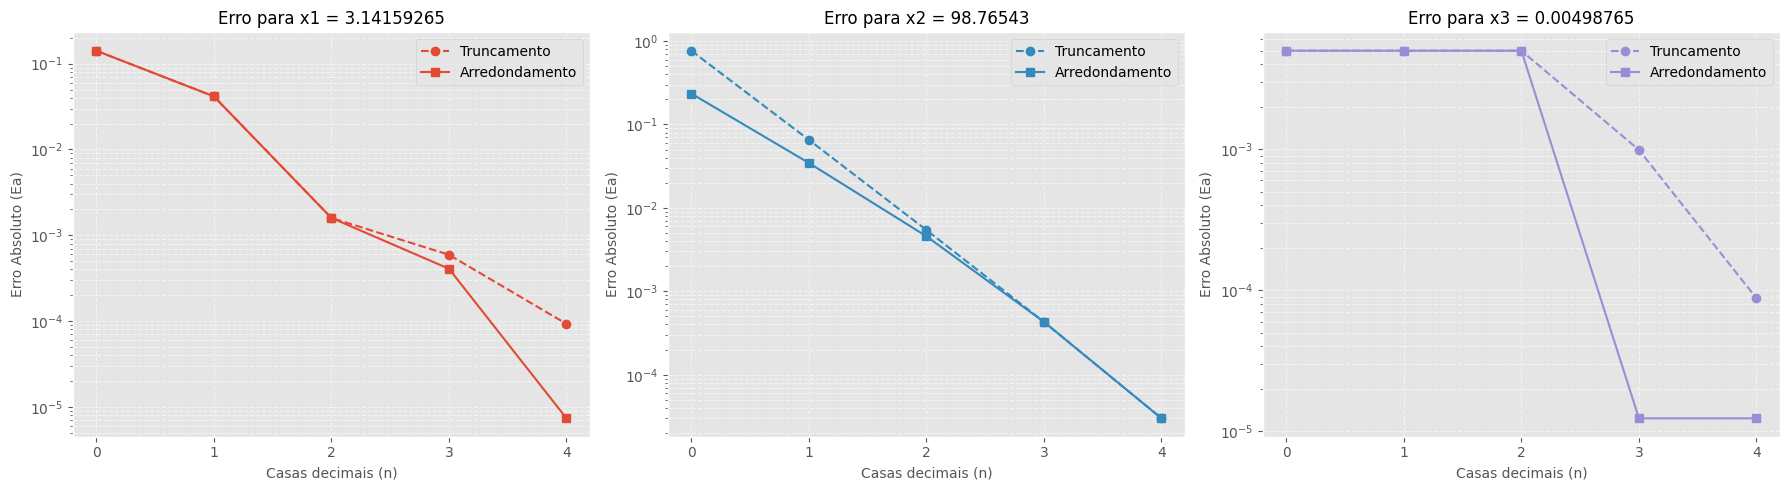

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

cores = ['#E24A33', '#348ABD', '#988ED5']
marcadores_trunc = 'o'
marcadores_arred = 's'

for i, nome in enumerate(nomes_x):
    df_filtrado = df_resultados[df_resultados['Var'] == nome]

    ax = axs[i]

    ax.plot(df_filtrado['n'], df_filtrado['Ea (Trunc)'],
             marker=marcadores_trunc, linestyle='--', color=cores[i],
             label='Truncamento')

    ax.plot(df_filtrado['n'], df_filtrado['Ea (Arred)'],
             marker=marcadores_arred, linestyle='-', color=cores[i],
             label='Arredondamento')

    ax.set_yscale('log')
    ax.set_xlabel('Casas decimais (n)', fontsize=10)
    ax.set_ylabel('Erro Absoluto (Ea)', fontsize=10)

    valor_real = df_filtrado['Valor Real'].iloc[0]
    ax.set_title(f'Erro para {nome} = {valor_real}', fontsize=12)

    ax.set_xticks(n_casas)
    ax.grid(True, which="both", ls="--", alpha=0.6)
    ax.legend()

plt.tight_layout()

plt.show()

## Resposta à Pergunta: arredondar sempre gera erro menor ou igual ao truncamento?

Como pudemos observar nos gráficos, o arredondamento sempre gera um erro menor, ou no máximo, igual ao erro de truncamento.

----------------------------------

# Parte B - Medida de Pressão Arterial.

Um equipamento registrou dez medidas consecutivas de pressão arterial sistólica, em mmHg: <br><br>
121,7; 120,4; 122,1; 119,8; 121,2; 120,9; 122,4; 121,0; 120,2; 121,5.<br><br>
Considere como referência a média calculada com todos os algarismos disponíveis.

In [ ]:
medidas_pressao = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

media_referencia = np.mean(medidas_pressao)

print(f"Média de Referência: {media_referencia} mmHg")

Média de Referência: 121.12 mmHg


### B1: Criação das séries

In [ ]:
dados_originais = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

dados_arredondados = np.round(dados_originais)
dados_truncados = np.trunc(dados_originais)

series = {
    'Originais': dados_originais,
    'Arredondados': dados_arredondados,
    'Truncados': dados_truncados
}

media_ref = np.mean(dados_originais)

def calcular_erros(valor_exato, valor_aprox):
    ea = abs(valor_exato - valor_aprox)
    er = ea / abs(valor_exato) if valor_exato != 0 else 0
    ep = er * 100
    return ea, er, ep

resultados_b1 = []

for nome, dados in series.items():
    media = np.mean(dados)
    minimo = np.min(dados)
    maximo = np.max(dados)
    amplitude = maximo - minimo

    desvio_padrao = np.std(dados, ddof=1)

    ea, er, ep = calcular_erros(media_ref, media)

    resultados_b1.append({
        'Série': nome,
        'Média': media,
        'Mínimo': minimo,
        'Máximo': maximo,
        'Amplitude': amplitude,
        'Desvio Padrão (s)': desvio_padrao,
        'Ea (Média)': ea,
        'Er (Média)': er,
        'E% (Média)': ep
    })

df_b1 = pd.DataFrame(resultados_b1)

pd.set_option('display.float_format', '{:.6f}'.format)
display(df_b1)

,Série,Média,Mínimo,Máximo,Amplitude,Desvio Padrão (s),Ea (Média),Er (Média),E% (Média)
0,Originais,121.120000,119.800000,122.400000,2.600000,0.833733,0.000000,0.000000,0.000000
1,Arredondados,121.100000,120.000000,122.000000,2.000000,0.875595,0.020000,0.000165,0.016513
2,Truncados,120.700000,119.000000,122.000000,3.000000,0.948683,0.420000,0.003468,0.346764


### B2: Geração dos Gráficos

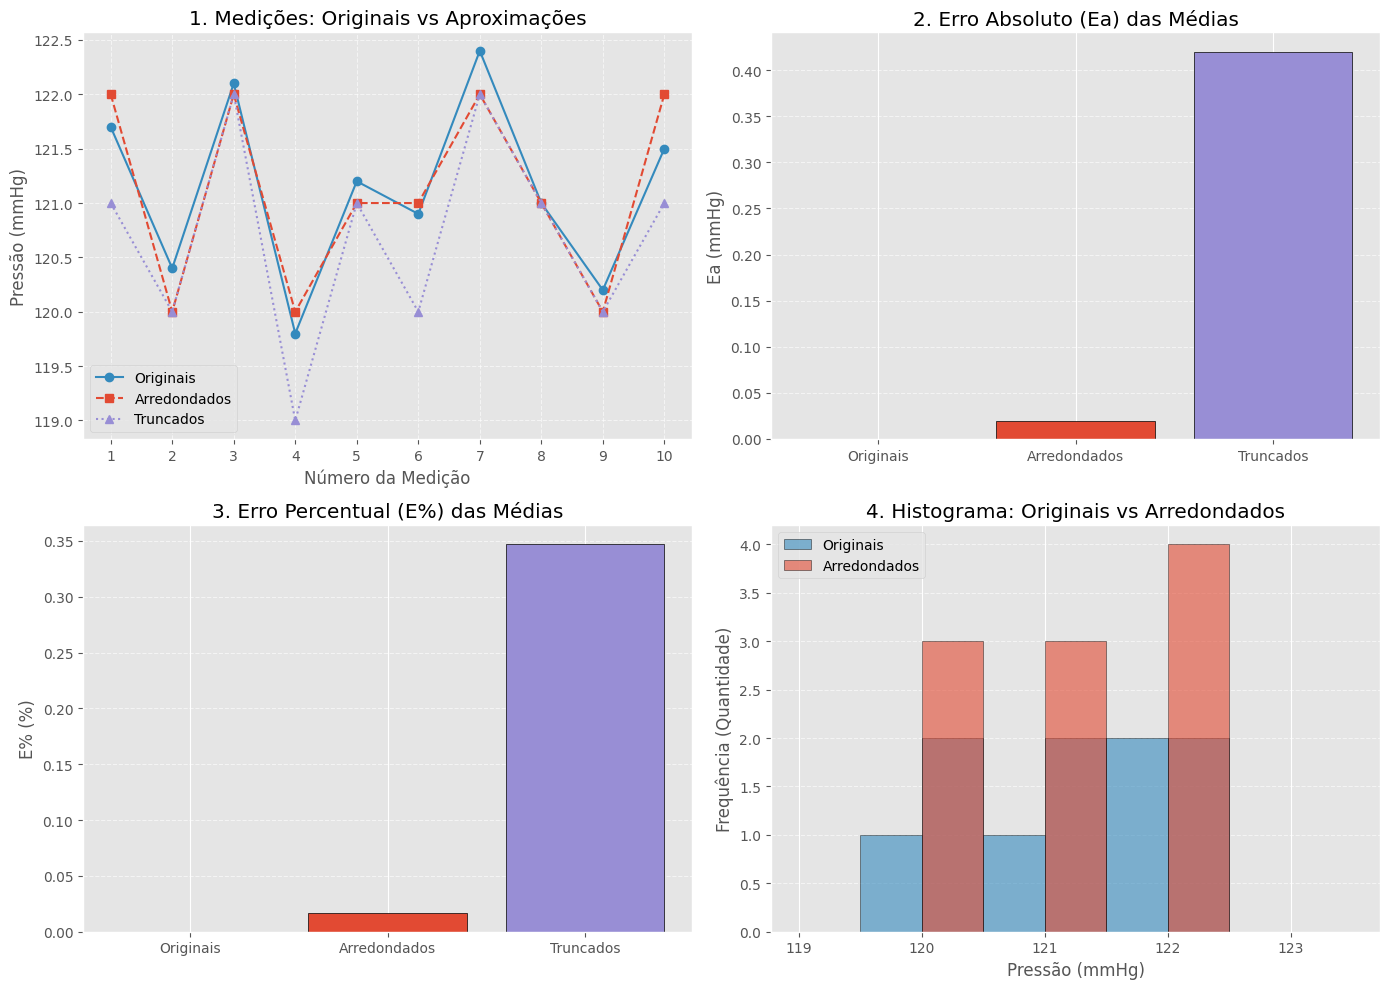

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

indices = np.arange(1, 11)

axs[0, 0].plot(indices, dados_originais, marker='o', label='Originais', color='#348ABD')
axs[0, 0].plot(indices, dados_arredondados, marker='s', label='Arredondados', color='#E24A33', linestyle='--')
axs[0, 0].plot(indices, dados_truncados, marker='^', label='Truncados', color='#988ED5', linestyle=':')

axs[0, 0].set_title('1. Medições: Originais vs Aproximações')
axs[0, 0].set_xlabel('Número da Medição')
axs[0, 0].set_ylabel('Pressão (mmHg)')
axs[0, 0].set_xticks(indices)
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.6)

nomes_series = df_b1['Série']
erros_abs = df_b1['Ea (Média)']
cores_barras = ['#8EBA42', '#E24A33', '#988ED5']

axs[0, 1].bar(nomes_series, erros_abs, color=cores_barras, edgecolor='black')
axs[0, 1].set_title('2. Erro Absoluto (Ea) das Médias')
axs[0, 1].set_ylabel('Ea (mmHg)')
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.6)

erros_perc = df_b1['E% (Média)']

axs[1, 0].bar(nomes_series, erros_perc, color=cores_barras, edgecolor='black')
axs[1, 0].set_title('3. Erro Percentual (E%) das Médias')
axs[1, 0].set_ylabel('E% (%)')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

bins = np.arange(119, 124, 0.5)

axs[1, 1].hist(dados_originais, bins=bins, alpha=0.6, label='Originais', color='#348ABD', edgecolor='black')
axs[1, 1].hist(dados_arredondados, bins=bins, alpha=0.6, label='Arredondados', color='#E24A33', edgecolor='black')

axs[1, 1].set_title('4. Histograma: Originais vs Arredondados')
axs[1, 1].set_xlabel('Pressão (mmHg)')
axs[1, 1].set_ylabel('Frequência (Quantidade)')
axs[1, 1].legend()
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Resposta à Pergunta: A representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra?

Não, a representação inteira (seja por arredondamento ou truncamento) não é suficiente para preservar a variabilidade da amostra e insere erros na média.

----------------------------------

# Parte C - Vazão em um tudo de pequeno diâmetro.

Adotemos:<br>
r = 0,80 mm, L = 0,20 m, μ = 3,5 × 10−3 Pa s, ∆p = 1200 Pa.

### C1

In [ ]:
def calcular_Q(r_m, mu, delta_p, L=0.20):
    return (math.pi * (r_m**4) * delta_p) / (8 * mu * L)

r_mm_exato = 0.80
mu_exato = 3.5e-3 # 0.0035
dp_exato = 1200
L_exato = 0.20

Q_ref = calcular_Q(r_mm_exato * 1e-3, mu_exato, dp_exato, L_exato)

resultados_c1 = []

def registrar_cenario(nome, tipo_aprox, r_mm, mu, dp):
    Q_aprox = calcular_Q(r_mm * 1e-3, mu, dp, L_exato)
    ea = erro_abs(Q_ref, Q_aprox)
    ep = erro_pct(Q_ref, Q_aprox)

    resultados_c1.append({
        'Cenário': nome,
        'Método': tipo_aprox,
        'r (mm)': r_mm,
        'mu (Pa.s)': mu,
        'dp (Pa)': dp,
        'Q (m³/s)': Q_aprox,
        'Erro Absoluto (Ea)': ea,
        'Erro % (E%)': ep
    })

registrar_cenario('2. Apenas r', 'Arredondamento', round(r_mm_exato, 1), mu_exato, dp_exato)
registrar_cenario('2. Apenas r', 'Truncamento', truncar(r_mm_exato, 1), mu_exato, dp_exato)

registrar_cenario('3. Apenas mu', 'Arredondamento', r_mm_exato, round(mu_exato, 3), dp_exato)
registrar_cenario('3. Apenas mu', 'Truncamento', r_mm_exato, truncar(mu_exato, 3), dp_exato)

dp_arred = round(dp_exato, -2)
dp_trunc = math.trunc(dp_exato / 100) * 100

registrar_cenario('4. Apenas dp', 'Arredondamento', r_mm_exato, mu_exato, dp_arred)
registrar_cenario('4. Apenas dp', 'Truncamento', r_mm_exato, mu_exato, dp_trunc)

registrar_cenario('5. Todas Variáveis', 'Arredondamento',
                  round(r_mm_exato, 1), round(mu_exato, 3), dp_arred)

registrar_cenario('5. Todas Variáveis', 'Truncamento',
                  truncar(r_mm_exato, 1), truncar(mu_exato, 3), dp_trunc)

df_c1 = pd.DataFrame(resultados_c1)

pd.set_option('display.float_format', '{:.4e}'.format)
display(df_c1)

,Cenário,Método,r (mm),mu (Pa.s),dp (Pa),Q (m³/s),Erro Absoluto (Ea),Erro % (E%)
0,2. Apenas r,Arredondamento,8.0000e-01,3.5000e-03,1200,2.7574e-07,0.0000e+00,0.0000e+00
1,2. Apenas r,Truncamento,8.0000e-01,3.5000e-03,1200,2.7574e-07,0.0000e+00,0.0000e+00
2,3. Apenas mu,Arredondamento,8.0000e-01,4.0000e-03,1200,2.4127e-07,3.4468e-08,1.2500e+01
3,3. Apenas mu,Truncamento,8.0000e-01,3.0000e-03,1200,3.2170e-07,4.5957e-08,1.6667e+01
4,4. Apenas dp,Arredondamento,8.0000e-01,3.5000e-03,1200,2.7574e-07,0.0000e+00,0.0000e+00
5,4. Apenas dp,Truncamento,8.0000e-01,3.5000e-03,1200,2.7574e-07,0.0000e+00,0.0000e+00
6,5. Todas Variáveis,Arredondamento,8.0000e-01,4.0000e-03,1200,2.4127e-07,3.4468e-08,1.2500e+01
7,5. Todas Variáveis,Truncamento,8.0000e-01,3.0000e-03,1200,3.2170e-07,4.5957e-08,1.6667e+01


### C2

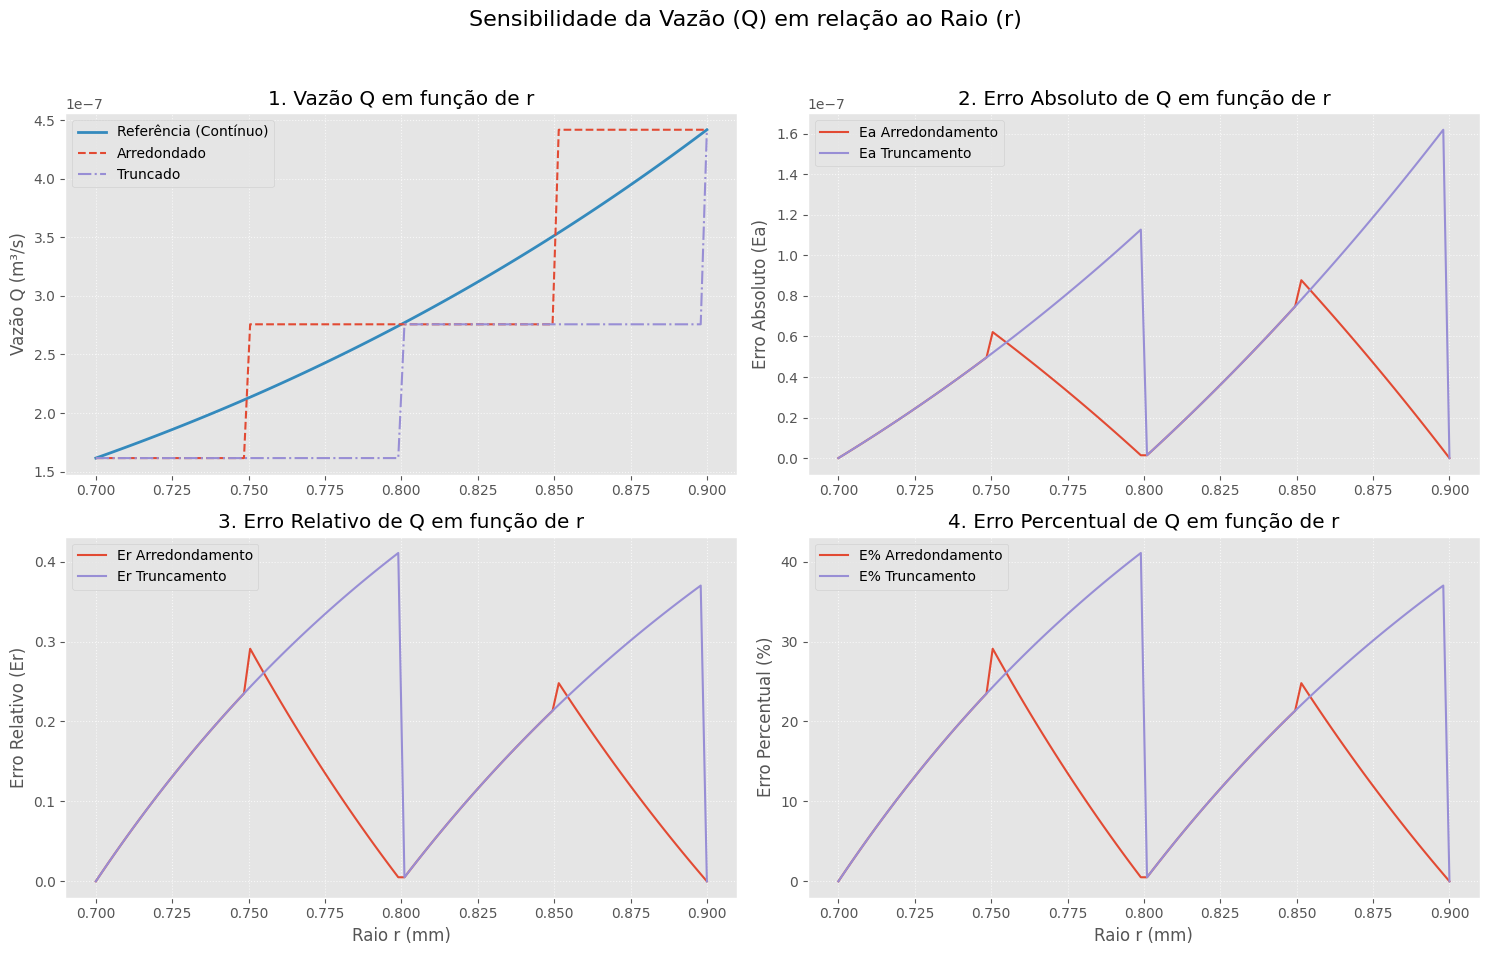

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

mu_exato = 3.5e-3
dp_exato = 1200
L_exato = 0.20

def calcular_Q(r_mm):
    r_m = r_mm * 1e-3
    return (math.pi * (r_m**4) * dp_exato) / (8 * mu_exato * L_exato)

r_vetor = np.linspace(0.70, 0.90, 100)

r_arred = np.round(r_vetor, 1)
r_trunc = np.trunc(r_vetor * 10) / 10

Q_ref = calcular_Q(r_vetor)
Q_arred = calcular_Q(r_arred)
Q_trunc = calcular_Q(r_trunc)

Ea_arred = np.abs(Q_ref - Q_arred)
Ea_trunc = np.abs(Q_ref - Q_trunc)

Er_arred = np.where(Q_ref != 0, np.abs(Q_ref - Q_arred) / np.abs(Q_ref), 0)
Er_trunc = np.where(Q_ref != 0, np.abs(Q_ref - Q_trunc) / np.abs(Q_ref), 0)

Eperc_arred = Er_arred * 100
Eperc_trunc = Er_trunc * 100

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sensibilidade da Vazão (Q) em relação ao Raio (r)', fontsize=16)

c_ref, c_arred, c_trunc = '#348ABD', '#E24A33', '#988ED5'

axs[0, 0].plot(r_vetor, Q_ref, label='Referência (Contínuo)', color=c_ref, linewidth=2)
axs[0, 0].plot(r_vetor, Q_arred, label='Arredondado', color=c_arred, linestyle='--')
axs[0, 0].plot(r_vetor, Q_trunc, label='Truncado', color=c_trunc, linestyle='-.')
axs[0, 0].set_title('1. Vazão Q em função de r')
axs[0, 0].set_ylabel('Vazão Q (m³/s)')
axs[0, 0].legend()

axs[0, 1].plot(r_vetor, Ea_arred, label='Ea Arredondamento', color=c_arred)
axs[0, 1].plot(r_vetor, Ea_trunc, label='Ea Truncamento', color=c_trunc)
axs[0, 1].set_title('2. Erro Absoluto de Q em função de r')
axs[0, 1].set_ylabel('Erro Absoluto (Ea)')
axs[0, 1].legend()

axs[1, 0].plot(r_vetor, Er_arred, label='Er Arredondamento', color=c_arred)
axs[1, 0].plot(r_vetor, Er_trunc, label='Er Truncamento', color=c_trunc)
axs[1, 0].set_title('3. Erro Relativo de Q em função de r')
axs[1, 0].set_xlabel('Raio r (mm)')
axs[1, 0].set_ylabel('Erro Relativo (Er)')
axs[1, 0].legend()

axs[1, 1].plot(r_vetor, Eperc_arred, label='E% Arredondamento', color=c_arred)
axs[1, 1].plot(r_vetor, Eperc_trunc, label='E% Truncamento', color=c_trunc)
axs[1, 1].set_title('4. Erro Percentual de Q em função de r')
axs[1, 1].set_xlabel('Raio r (mm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].legend()

for ax in axs.flat:
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Resposta à Pergunta: Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente quatro.

O erro no raio é amplificado drasticamente na vazão devido à relação de potência descrita pela equação de Hagen-Poiseuille, onde a vazão $Q$ é diretamente proporcional à quarta potência do raio ($Q \propto r^4$).

---



# Parte D - Escoamento em um Nanocateter

Considere um modelo didático de nanocateter cilíndrico:
<br>
r = 50 nm, L = 10 μm, μ = 3,5 × 10−3 Pa s, ∆p = 5000 Pa.
<br>
Use novamente Hagen–Poiseuille para calcular Q.

### D1

<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:56: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1387/3723496442.py:36: SyntaxWarning: invalid escape sequence '\D'
  axs[0, 0].set_title('1. Vazões Q em função do erro $\Delta r$')
/tmp/ipykernel_1387/3723496442.py:37: SyntaxWarning: invalid escape sequence '\D'
  axs[0, 0].set_xlabel('$\Delta r$ (nm)')
/tmp/ipykernel_1387/3723496442.py:43: SyntaxWarning: invalid escape sequence '\D'
  axs[0, 1].set_xlabel('$\Delta r$

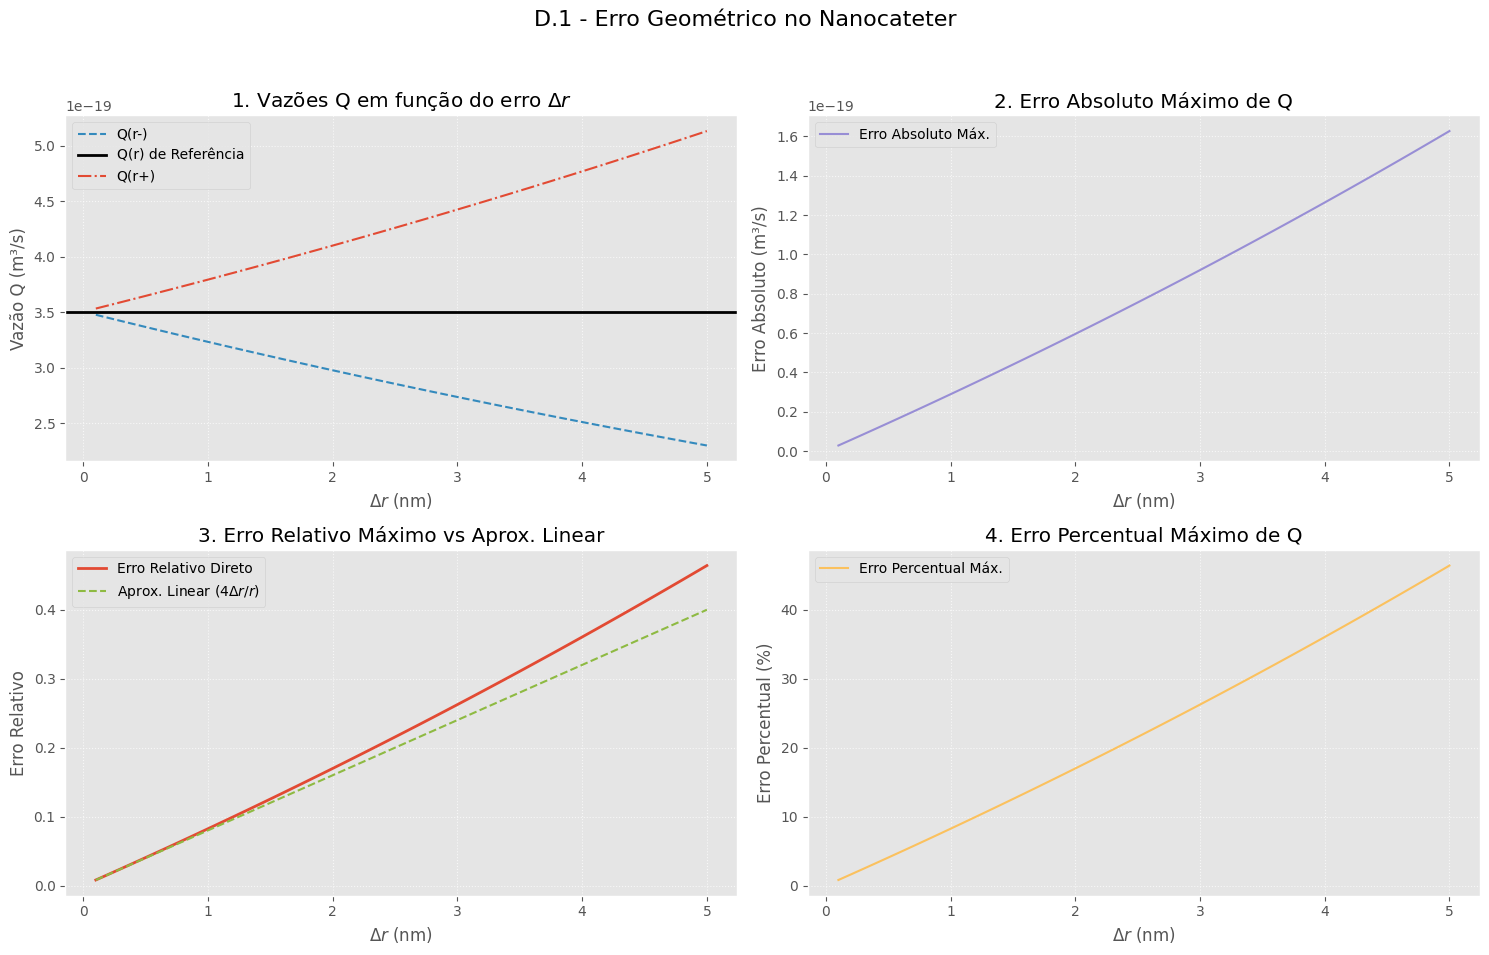

In [ ]:
r_nm_exato = 50.0
r_exato = r_nm_exato * 1e-9      # Convertendo nm para metros
L_exato = 10.0 * 1e-6            # Convertendo um para metros
mu_exato = 3.5e-3                # Pa.s
dp_exato = 5000.0                # Pa

def calcular_Q(r_val):
    return (math.pi * (r_val**4) * dp_exato) / (8 * mu_exato * L_exato)

Q_ref = calcular_Q(r_exato)

dr_nm = np.arange(0.1, 5.1, 0.1)
dr = dr_nm * 1e-9 # Convertendo para metros

r_minus = r_exato - dr
r_plus = r_exato + dr

Q_minus = calcular_Q(r_minus)
Q_plus = calcular_Q(r_plus)

Ea_minus = np.abs(Q_minus - Q_ref)
Ea_plus = np.abs(Q_plus - Q_ref)
Ea_max = np.maximum(Ea_minus, Ea_plus)

Er_max = Ea_max / Q_ref
Eperc_max = Er_max * 100

Er_aprox_linear = 4 * (dr / r_exato)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('D.1 - Erro Geométrico no Nanocateter', fontsize=16)

axs[0, 0].plot(dr_nm, Q_minus, label='Q(r-)', color='#348ABD', linestyle='--')
axs[0, 0].axhline(Q_ref, label='Q(r) de Referência', color='black', linewidth=2)
axs[0, 0].plot(dr_nm, Q_plus, label='Q(r+)', color='#E24A33', linestyle='-.')
axs[0, 0].set_title('1. Vazões Q em função do erro $\Delta r$')
axs[0, 0].set_xlabel('$\Delta r$ (nm)')
axs[0, 0].set_ylabel('Vazão Q (m³/s)')
axs[0, 0].legend()

axs[0, 1].plot(dr_nm, Ea_max, label='Erro Absoluto Máx.', color='#988ED5')
axs[0, 1].set_title('2. Erro Absoluto Máximo de Q')
axs[0, 1].set_xlabel('$\Delta r$ (nm)')
axs[0, 1].set_ylabel('Erro Absoluto (m³/s)')
axs[0, 1].legend()

axs[1, 0].plot(dr_nm, Er_max, label='Erro Relativo Direto', color='#E24A33', linewidth=2)
axs[1, 0].plot(dr_nm, Er_aprox_linear, label='Aprox. Linear ($4\Delta r/r$)', color='#8EBA42', linestyle='--')
axs[1, 0].set_title('3. Erro Relativo Máximo vs Aprox. Linear')
axs[1, 0].set_xlabel('$\Delta r$ (nm)')
axs[1, 0].set_ylabel('Erro Relativo')
axs[1, 0].legend()

axs[1, 1].plot(dr_nm, Eperc_max, label='Erro Percentual Máx.', color='#FBC15E')
axs[1, 1].set_title('4. Erro Percentual Máximo de Q')
axs[1, 1].set_xlabel('$\Delta r$ (nm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].legend()

for ax in axs.flat:
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Comparando o erro direto com a aproximação Linear:

A aproximação linear provém do uso da diferencial e da série de Taylor de primeira ordem. Como a vazão é $Q \propto r^4$, a propagação do erro relativo se aproxima de $4$ vezes o erro relativo do raio.
<br>
Ao observar o Gráfico 3, notamos que para pequenos valores de $\Delta r$ (por exemplo, entre $0,1 \text{ nm}$ e $1,0 \text{ nm}$), o cálculo direto e a aproximação linear são praticamente idênticos (as linhas se sobrepõem). No entanto, à medida que o erro $\Delta r$ cresce em direção a $5,0 \text{ nm}$ (o que representa $10\%$ do raio original de $50 \text{ nm}$), as curvas começam a se distanciar sutilmente. Isso ocorre porque, para erros maiores, os termos de ordem superior da expansão polinomial de $(r + \Delta r)^4$ ganham peso, e a aproximação puramente linear perde sua precisão, subestimando o erro real.

### D2

In [ ]:
r_val = 50.0e-9
L_val = 10.0e-6
mu_val = 3.5e-3
dp_val = 5000.0

r_32 = np.float32(r_val)
L_32 = np.float32(L_val)
mu_32 = np.float32(mu_val)
dp_32 = np.float32(dp_val)
pi_32 = np.float32(math.pi)

r4_32 = r_32 ** np.float32(4.0)
Q_32 = (pi_32 * r4_32 * dp_32) / (np.float32(8.0) * mu_32 * L_32)
eps_32 = np.finfo(np.float32).eps

r_64 = np.float64(r_val)
L_64 = np.float64(L_val)
mu_64 = np.float64(mu_val)
dp_64 = np.float64(dp_val)
pi_64 = np.float64(math.pi)

r4_64 = r_64 ** np.float64(4.0)
Q_64 = (pi_64 * r4_64 * dp_64) / (np.float64(8.0) * mu_64 * L_64)
eps_64 = np.finfo(np.float64).eps

diff_abs = np.abs(np.float64(Q_64) - np.float64(Q_32))
diff_rel = diff_abs / np.float64(Q_64)

print("--- r^4 ---")
print(f"r^4 (float32): {r4_32}")
print(f"r^4 (float64): {r4_64}\n")

print("--- Q ---")
print(f"Q (float32): {Q_32}")
print(f"Q (float64): {Q_64}\n")

print("--- Diferenças entre as precisões ---")
print(f"Diferença Absoluta: {diff_abs}")
print(f"Diferença Relativa: {diff_rel}\n")

print("--- Épsilon da Máquina (eps) ---")
print(f"eps (float32): {eps_32}")
print(f"eps (float64): {eps_64}")

--- r^4 ---
r^4 (float32): 6.2500003959774226e-30
r^4 (float64): 6.249999999999999e-30

--- Q ---
Q (float32): 3.506242323744234e-19
Q (float64): 3.506241800881465e-19

--- Diferenças entre as precisões ---
Diferença Absoluta: 5.228627689184328e-26
Diferença Relativa: 1.4912342006389455e-07

--- Épsilon da Máquina (eps) ---
eps (float32): 1.1920928955078125e-07
eps (float64): 2.220446049250313e-16


In [ ]:
razoes_dr_r = np.logspace(-1, -16, 16, dtype=np.float64)

def calc_Q(r):
    return (pi_64 * (r**4) * dp_64) / (np.float64(8.0) * mu_64 * L_64)

Q_ref_64 = calc_Q(r_64)
resultados_cancelamento = []

for razao in razoes_dr_r:
    r_plus = r_64 * (1.0 + razao)
    Q_plus = calc_Q(r_plus)

    delta_1 = (Q_plus - Q_ref_64) / Q_ref_64

    delta_2 = ((1.0 + razao)**4) - 1.0

    resultados_cancelamento.append({
        'Δr/r': razao,
        'δ1 (Eq. 6)': delta_1,
        'δ2 (Eq. 7)': delta_2,
        '|δ1 - δ2|': np.abs(delta_1 - delta_2)
    })

df_cancelamento = pd.DataFrame(resultados_cancelamento)
pd.set_option('display.float_format', '{:.4e}'.format)
display(df_cancelamento)

,Δr/r,δ1 (Eq. 6),δ2 (Eq. 7),|δ1 - δ2|
0,1.0000e-01,4.6410e-01,4.6410e-01,2.7756e-16
1,1.0000e-02,4.0604e-02,4.0604e-02,3.6082e-16
2,1.0000e-03,4.0060e-03,4.0060e-03,2.2378e-16
3,1.0000e-04,4.0006e-04,4.0006e-04,1.2956e-17
4,1.0000e-05,4.0001e-05,4.0001e-05,5.0117e-16
5,1.0000e-06,4.0000e-06,4.0000e-06,2.8817e-16
6,1.0000e-07,4.0000e-07,4.0000e-07,8.8008e-17
7,1.0000e-08,4.0000e-08,4.0000e-08,2.3184e-16
8,1.0000e-09,4.0000e-09,4.0000e-09,9.2128e-17
9,1.0000e-10,4.0000e-10,4.0000e-10,4.5194e-18


### Análise: Perda de Significância por Cancelamento

**Identifique possível perda de significância por cancelamento:**

**Resposta:**
A perda de significância (ou cancelamento subtrativo) ocorre quando subtraímos dois valores em ponto flutuante que são extremamente próximos um do outro.

Ao analisar a tabela gerada, comparando as duas expressões para valores progressivamente menores de $\frac{\Delta r}{r}$, nota-se que:

1.  **Cancelamento na Expressão $\delta_1$ (Equação 6):** Conforme $\Delta r \to 0$, as vazões $Q(r+\Delta r)$ e $Q(r)$ tornam-se quase idênticas. A operação de subtração no numerador anula os dígitos mais significativos de ambos os números. Os dígitos que sobram são essencialmente "ruído" decorrente de arredondamentos de máquina. Quando a variação torna-se menor que o épsilon da máquina (`eps`), o computador enxerga $Q(r+\Delta r) = Q(r)$, resultando em $\delta_1 = 0$, perdendo totalmente a precisão do cálculo da variação.

2.  **Cancelamento na Expressão $\delta_2$ (Equação 7):** A expressão simplificada atenua o problema ao remover a diferença direta das vazões, mas esbarra no mesmo limite computacional. Quando a razão $\frac{\Delta r}{r}$ é menor que o épsilon da máquina, a soma $(1 + \frac{\Delta r}{r})$ é truncada pelo computador para simplesmente $1$. Consequentemente, $1^4 - 1 = 0$.

**Conclusão:**
Ambas as expressões falham em computar variações infinitesimais por limitações do hardware (o `float64` tem limite de precisão na casa de $\approx 10^{-16}$). A Equação 7 é computacionalmente mais elegante e barata (exige menos operações), mas para cálculos que demandam perturbações muito menores do que o `eps`, até a álgebra tradicional deve ser repensada para evitar subtrações de números muito próximos.

### D.3 Fenômeno físico

À medida que a escala geométrica de um tubo é reduzida para dimensões nanométricas, o volume do fluido diminui de forma cúbica ($r^3$), enquanto a área da parede interna do canal diminui apenas de forma quadrática ($r^2$). Isso resulta em um aumento drástico da razão superfície/volume. Consequentemente, as forças de superfície — como o atrito viscoso e a tensão de cisalhamento na parede do nanocateter — passam a dominar o comportamento do fluido, superando amplamente as forças inerciais. É por isso que perturbações minúsculas na geometria causam impactos massivos no escoamento, mostrando que uma alta precisão aritmética no cálculo não garante a validade física se o modelo negligenciar a rugosidade ou interações moleculares da parede.

---



# Parte E - Síntese Visual

<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1387/1541461543.py:73: SyntaxWarning: invalid escape sequence '\p'
  "sensibilidade geométrica ($Q \propto r^4$).\n"
/tmp/ipykernel_1387/1541461543.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


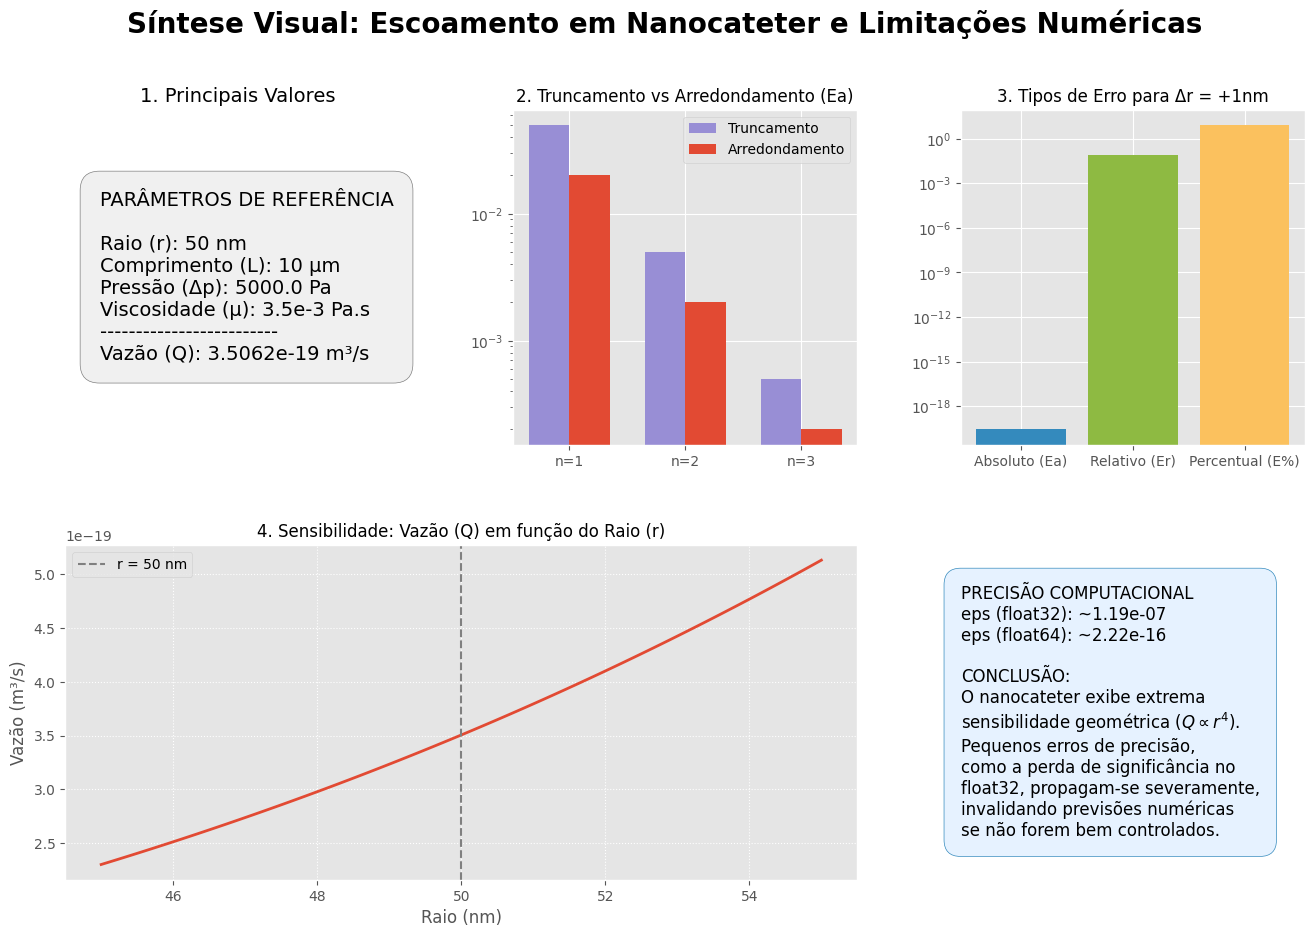

Quadro PNG gerado e salvo como 'sintese_resultados.png' (1600x1000px).


In [ ]:
from matplotlib.gridspec import GridSpec

r_ref = 50e-9
L_ref = 10e-6
mu_ref = 3.5e-3
dp_ref = 5000.0

def calc_Q(r):
    return (math.pi * (r**4) * dp_ref) / (8 * mu_ref * L_ref)

Q_ref = calc_Q(r_ref)

fig = plt.figure(figsize=(16, 10), dpi=100)
gs = GridSpec(2, 3, figure=fig, wspace=0.3, hspace=0.3)
fig.suptitle('Síntese Visual: Escoamento em Nanocateter e Limitações Numéricas', fontsize=20, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
texto_cartoes = (
    "PARÂMETROS DE REFERÊNCIA\n\n"
    f"Raio (r): 50 nm\n"
    f"Comprimento (L): 10 µm\n"
    f"Pressão (Δp): {dp_ref} Pa\n"
    f"Viscosidade (µ): 3.5e-3 Pa.s\n"
    "-------------------------\n"
    f"Vazão (Q): {Q_ref:.4e} m³/s"
)
ax1.text(0.1, 0.5, texto_cartoes, fontsize=14, va='center', bbox=dict(facecolor='#f0f0f0', edgecolor='gray', boxstyle='round,pad=1'))
ax1.set_title("1. Principais Valores", fontsize=14)

ax2 = fig.add_subplot(gs[0, 1])
labels = ['n=1', 'n=2', 'n=3']
erro_trunc = [0.05, 0.005, 0.0005]
erro_arred = [0.02, 0.002, 0.0002]
x = np.arange(len(labels))
width = 0.35
ax2.bar(x - width/2, erro_trunc, width, label='Truncamento', color='#988ED5')
ax2.bar(x + width/2, erro_arred, width, label='Arredondamento', color='#E24A33')
ax2.set_yscale('log')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("2. Truncamento vs Arredondamento (Ea)", fontsize=12)
ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
Q_erro = calc_Q(51e-9)
ea = abs(Q_erro - Q_ref)
er = ea / Q_ref
ep = er * 100
ax3.bar(['Absoluto (Ea)', 'Relativo (Er)', 'Percentual (E%)'], [ea, er, ep], color=['#348ABD', '#8EBA42', '#FBC15E'])
ax3.set_yscale('log')
ax3.set_title("3. Tipos de Erro para Δr = +1nm", fontsize=12)

ax4 = fig.add_subplot(gs[1, 0:2])
raios = np.linspace(45e-9, 55e-9, 100)
vazoes = calc_Q(raios)
ax4.plot(raios * 1e9, vazoes, color='#E24A33', linewidth=2)
ax4.axvline(50, color='gray', linestyle='--', label='r = 50 nm')
ax4.set_xlabel('Raio (nm)')
ax4.set_ylabel('Vazão (m³/s)')
ax4.set_title("4. Sensibilidade: Vazão (Q) em função do Raio (r)", fontsize=12)
ax4.grid(True, linestyle=':')
ax4.legend()

ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
texto_conclusao = (
    "PRECISÃO COMPUTACIONAL\n"
    "eps (float32): ~1.19e-07\n"
    "eps (float64): ~2.22e-16\n\n"
    "CONCLUSÃO:\n"
    "O nanocateter exibe extrema\n"
    "sensibilidade geométrica ($Q \propto r^4$).\n"
    "Pequenos erros de precisão,\n"
    "como a perda de significância no\n"
    "float32, propagam-se severamente,\n"
    "invalidando previsões numéricas\n"
    "se não forem bem controlados."
)
ax5.text(0.0, 0.5, texto_conclusao, fontsize=12, va='center', bbox=dict(facecolor='#e6f2ff', edgecolor='#348ABD', boxstyle='round,pad=1'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('sintese_resultados.png', format='png')
plt.show()
print("Quadro PNG gerado e salvo como 'sintese_resultados.png' (1600x1000px).")

---

# GIF Demonstrativo

GIF demonstrativo gerado com sucesso: nanocateter_animacao.gif


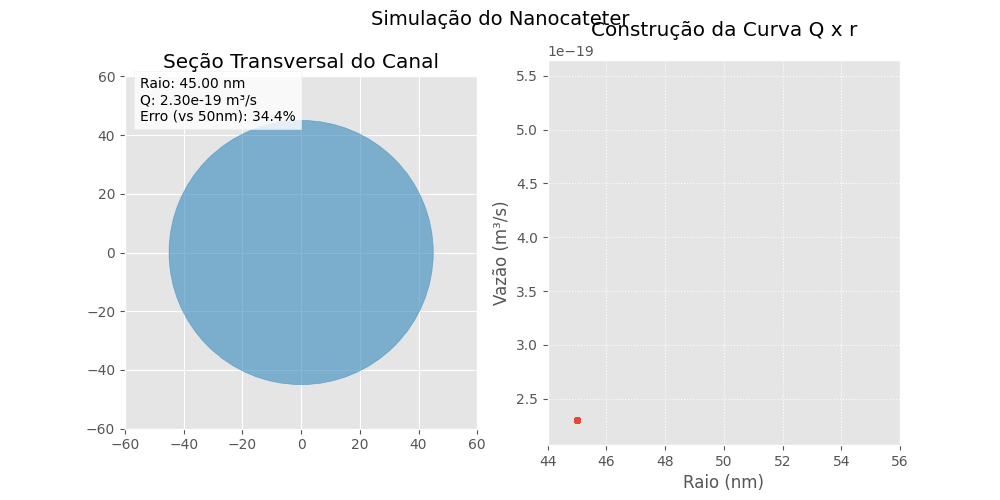

In [24]:
from matplotlib.animation import FuncAnimation

raios_nm = np.linspace(45, 55, 40) # 40 quadros
raios_m = raios_nm * 1e-9
dp = 5000.0
mu = 3.5e-3
L = 10e-6
Q_ref = (math.pi * ((50e-9)**4) * dp) / (8 * mu * L)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Simulação do Nanocateter', fontsize=14)

ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_aspect('equal')
ax1.set_title('Seção Transversal do Canal')
circulo = plt.Circle((0, 0), raios_nm[0], color='#348ABD', alpha=0.6)
ax1.add_patch(circulo)
texto_info = ax1.text(-55, 45, '', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

ax2.set_xlim(44, 56)
ax2.set_ylim(min((math.pi * (r**4) * dp) / (8 * mu * L) for r in raios_m) * 0.9,
             max((math.pi * (r**4) * dp) / (8 * mu * L) for r in raios_m) * 1.1)
ax2.set_title('Construção da Curva Q x r')
ax2.set_xlabel('Raio (nm)')
ax2.set_ylabel('Vazão (m³/s)')
ax2.grid(True, linestyle=':')
linha, = ax2.plot([], [], color='#E24A33', lw=2, marker='o', markersize=4)

hist_raios = []
hist_vazoes = []

def animar(i):
    r_atual_nm = raios_nm[i]
    r_atual_m = raios_m[i]
    Q_atual = (math.pi * (r_atual_m**4) * dp) / (8 * mu * L)

    erro_perc = abs(Q_atual - Q_ref) / Q_ref * 100

    circulo.set_radius(r_atual_nm)

    texto_info.set_text(f"Raio: {r_atual_nm:.2f} nm\nQ: {Q_atual:.2e} m³/s\nErro (vs 50nm): {erro_perc:.1f}%")

    hist_raios.append(r_atual_nm)
    hist_vazoes.append(Q_atual)
    linha.set_data(hist_raios, hist_vazoes)

    return circulo, texto_info, linha

ani = FuncAnimation(fig, animar, frames=len(raios_nm), interval=150, blit=True)

arquivo_gif = 'nanocateter_animacao.gif'
ani.save(arquivo_gif, writer='pillow')
plt.close()
print(f"GIF demonstrativo gerado com sucesso: {arquivo_gif}")

from IPython.display import Image
display(Image(open(arquivo_gif, 'rb').read()))

---

# Entrega Final - PDF concatenando todos os resultados

/tmp/ipykernel_1387/4218923013.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


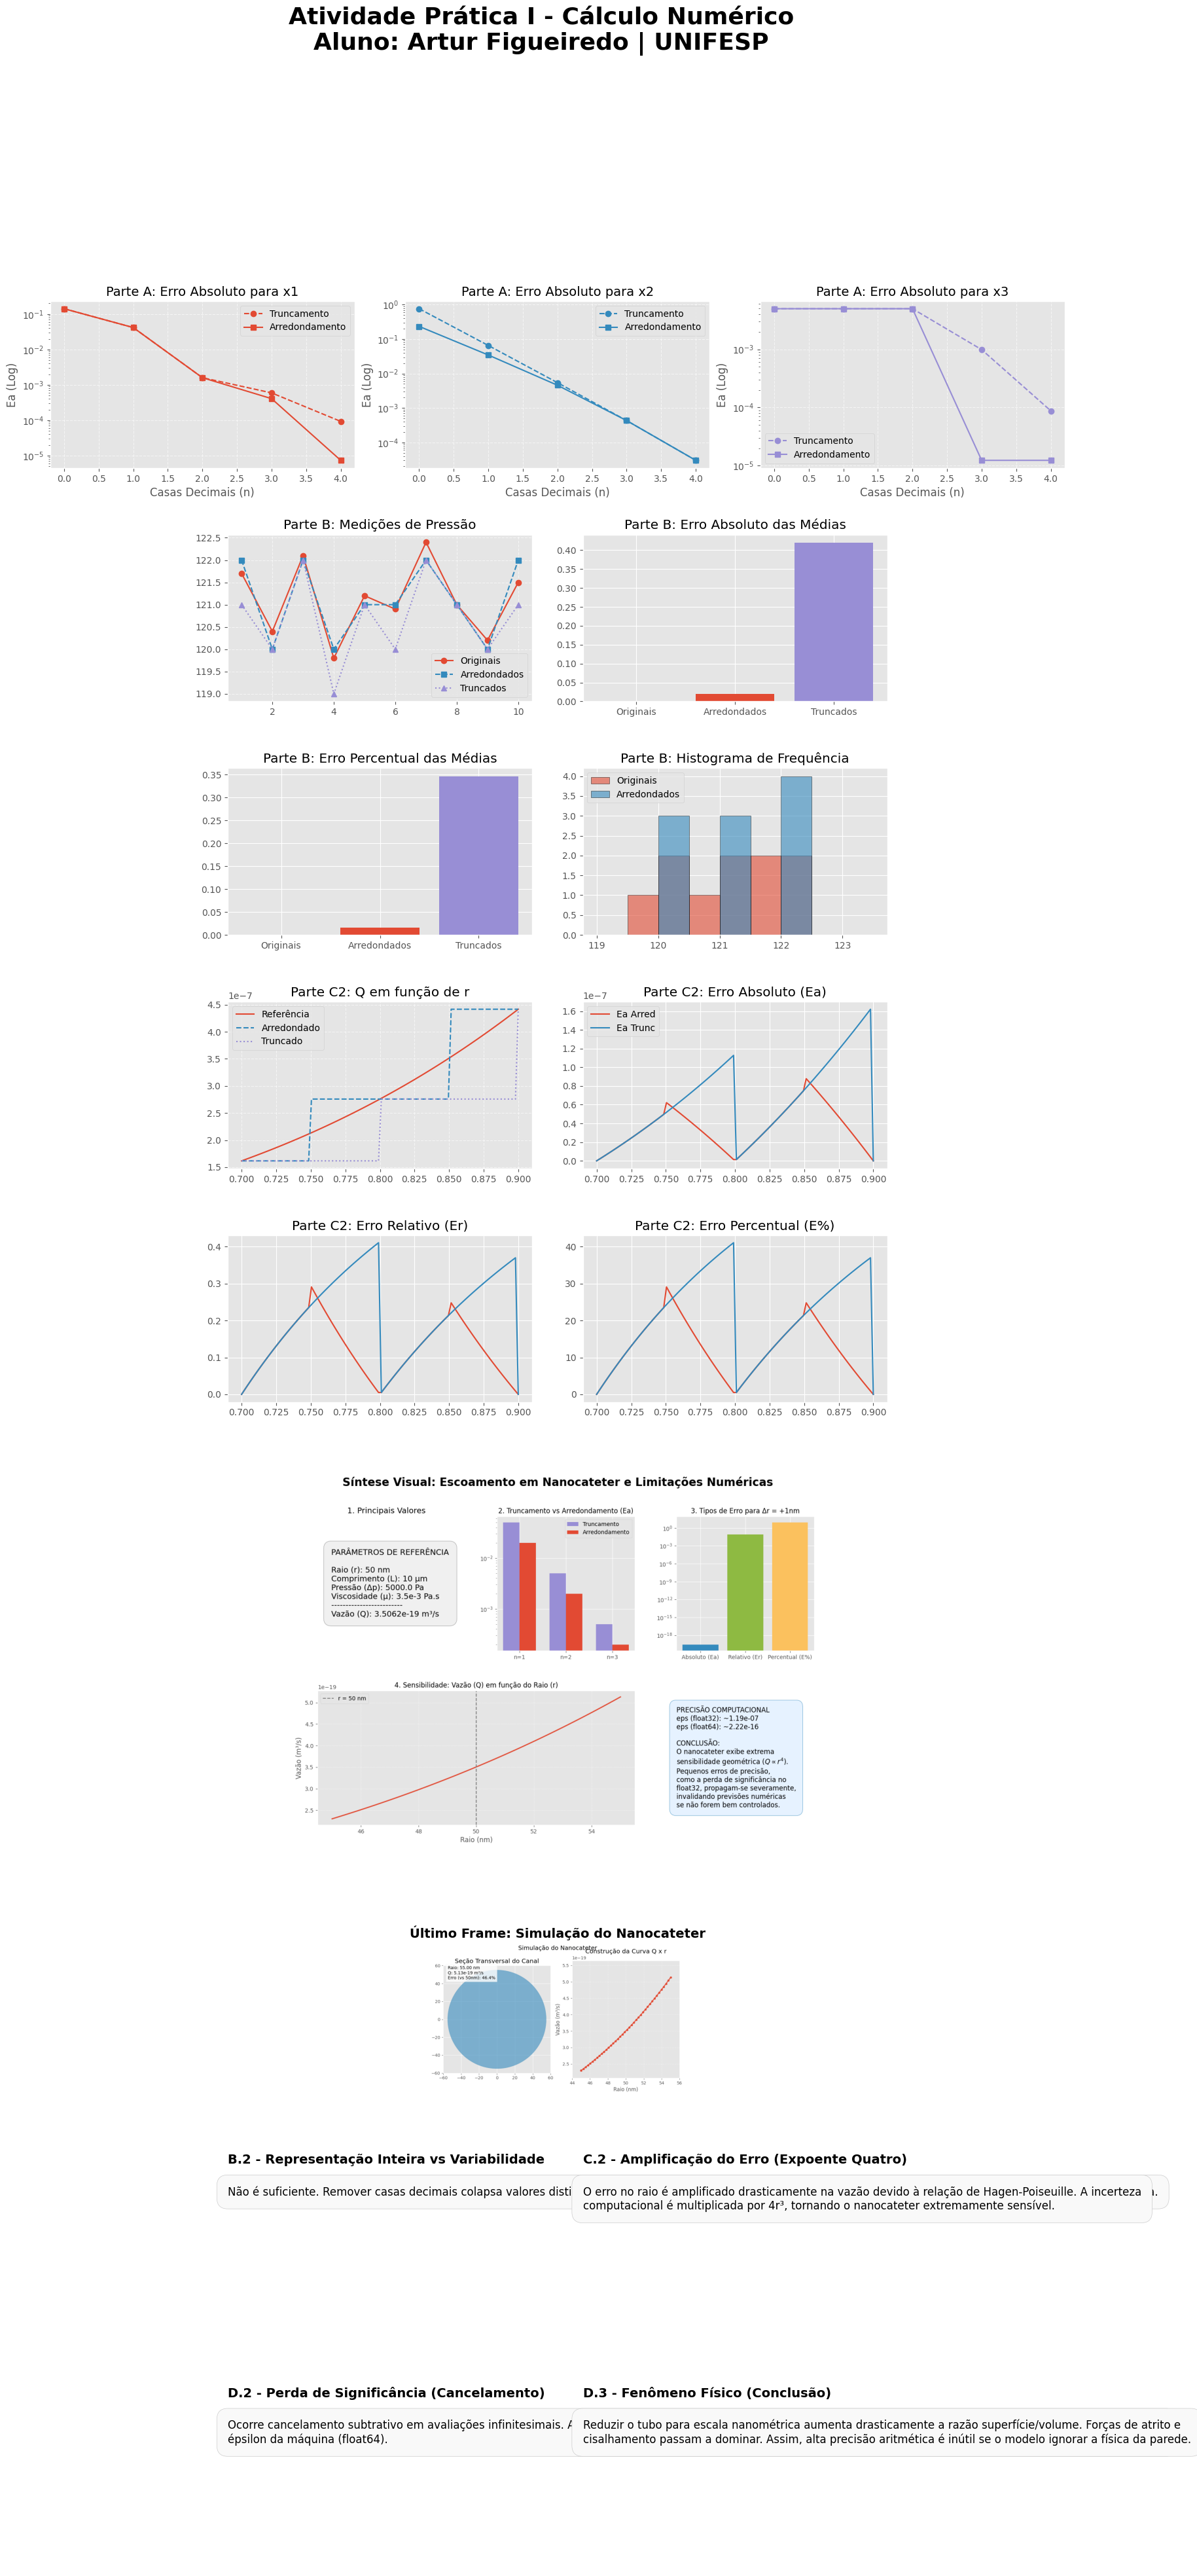

PDF finalizado e salvo como 'Relatorio_Final_Calculo_Numerico.pdf'!


In [26]:
from PIL import Image

fig = plt.figure(figsize=(20, 45))
gs = GridSpec(10, 6, figure=fig, hspace=0.4, wspace=0.4)

fig.suptitle("Atividade Prática I - Cálculo Numérico\nAluno: Artur Figueiredo | UNIFESP",
             fontsize=26, fontweight='bold', y=0.98)

try:
    nomes = ['x1', 'x2', 'x3']
    cores = ['#E24A33', '#348ABD', '#988ED5']
    for i, nome in enumerate(nomes):
        ax = fig.add_subplot(gs[0, i*2:(i+1)*2]) # Ocupa 2 colunas cada um
        df_filtrado = df_resultados[df_resultados['Var'] == nome]
        ax.plot(df_filtrado['n'], df_filtrado['Ea (Trunc)'], marker='o', linestyle='--', color=cores[i], label='Truncamento')
        ax.plot(df_filtrado['n'], df_filtrado['Ea (Arred)'], marker='s', linestyle='-', color=cores[i], label='Arredondamento')
        ax.set_yscale('log')
        ax.set_title(f"Parte A: Erro Absoluto para {nome}", fontsize=14)
        ax.set_xlabel("Casas Decimais (n)")
        ax.set_ylabel("Ea (Log)")
        ax.grid(True, ls="--", alpha=0.6)
        ax.legend()
except Exception as e:
    print(f"Aviso: Não foi possível carregar os gráficos da Parte A. ({e})")

try:
    ax_b1 = fig.add_subplot(gs[1, 1:3])
    ax_b1.plot(indices, dados_originais, marker='o', label='Originais')
    ax_b1.plot(indices, dados_arredondados, marker='s', label='Arredondados', ls='--')
    ax_b1.plot(indices, dados_truncados, marker='^', label='Truncados', ls=':')
    ax_b1.set_title('Parte B: Medições de Pressão')
    ax_b1.grid(True, ls="--", alpha=0.6)
    ax_b1.legend()

    ax_b2 = fig.add_subplot(gs[1, 3:5])
    ax_b2.bar(df_b1['Série'], df_b1['Ea (Média)'], color=['#8EBA42', '#E24A33', '#988ED5'])
    ax_b2.set_title('Parte B: Erro Absoluto das Médias')

    ax_b3 = fig.add_subplot(gs[2, 1:3])
    ax_b3.bar(df_b1['Série'], df_b1['E% (Média)'], color=['#8EBA42', '#E24A33', '#988ED5'])
    ax_b3.set_title('Parte B: Erro Percentual das Médias')

    ax_b4 = fig.add_subplot(gs[2, 3:5])
    ax_b4.hist(dados_originais, bins=bins, alpha=0.6, label='Originais', edgecolor='black')
    ax_b4.hist(dados_arredondados, bins=bins, alpha=0.6, label='Arredondados', edgecolor='black')
    ax_b4.set_title('Parte B: Histograma de Frequência')
    ax_b4.legend()
except Exception as e:
    print(f"Aviso: Não foi possível carregar os gráficos da Parte B. ({e})")

try:
    r_vetor_c2 = np.linspace(0.70, 0.90, 100)
    Q_ref_c2 = (math.pi * ((r_vetor_c2 * 1e-3)**4) * 1200) / (8 * 3.5e-3 * 0.20)
    Q_arr_c2 = (math.pi * ((np.round(r_vetor_c2, 1) * 1e-3)**4) * 1200) / (8 * 3.5e-3 * 0.20)
    Q_trc_c2 = (math.pi * ((np.trunc(r_vetor_c2 * 10) / 10 * 1e-3)**4) * 1200) / (8 * 3.5e-3 * 0.20)

    ax_c1 = fig.add_subplot(gs[3, 1:3])
    ax_c1.plot(r_vetor_c2, Q_ref_c2, label='Referência')
    ax_c1.plot(r_vetor_c2, Q_arr_c2, label='Arredondado', ls='--')
    ax_c1.plot(r_vetor_c2, Q_trc_c2, label='Truncado', ls=':')
    ax_c1.set_title('Parte C2: Q em função de r')
    ax_c1.grid(True, ls="--", alpha=0.6)
    ax_c1.legend()

    ax_c2 = fig.add_subplot(gs[3, 3:5])
    ax_c2.plot(r_vetor_c2, np.abs(Q_ref_c2 - Q_arr_c2), label='Ea Arred')
    ax_c2.plot(r_vetor_c2, np.abs(Q_ref_c2 - Q_trc_c2), label='Ea Trunc')
    ax_c2.set_title('Parte C2: Erro Absoluto (Ea)')
    ax_c2.legend()

    ax_c3 = fig.add_subplot(gs[4, 1:3])
    ax_c3.plot(r_vetor_c2, np.abs(Q_ref_c2 - Q_arr_c2)/Q_ref_c2, label='Er Arred')
    ax_c3.plot(r_vetor_c2, np.abs(Q_ref_c2 - Q_trc_c2)/Q_ref_c2, label='Er Trunc')
    ax_c3.set_title('Parte C2: Erro Relativo (Er)')

    ax_c4 = fig.add_subplot(gs[4, 3:5])
    ax_c4.plot(r_vetor_c2, (np.abs(Q_ref_c2 - Q_arr_c2)/Q_ref_c2)*100, label='E% Arred')
    ax_c4.plot(r_vetor_c2, (np.abs(Q_ref_c2 - Q_trc_c2)/Q_ref_c2)*100, label='E% Trunc')
    ax_c4.set_title('Parte C2: Erro Percentual (E%)')
except Exception as e:
    print(f"Aviso: Não foi possível carregar os gráficos da Parte C2. ({e})")

ax_sintese = fig.add_subplot(gs[5:7, 0:6]) # Ocupa todo o centro da página
ax_sintese.axis('off')
try:
    img_sintese = Image.open('sintese_resultados.png')
    ax_sintese.imshow(img_sintese)
except FileNotFoundError:
    ax_sintese.text(0.5, 0.5, "[Quadro Síntese não encontrado. Rode a célula da Parte E]", ha='center', fontsize=14)

ax_gif = fig.add_subplot(gs[7, 2:4])
ax_gif.axis('off')
try:
    img_gif = Image.open('nanocateter_animacao.gif')
    img_gif.seek(img_gif.n_frames - 1)
    ax_gif.imshow(img_gif)
    ax_gif.set_title("Último Frame: Simulação do Nanocateter", fontsize=14, fontweight='bold')
except FileNotFoundError:
    ax_gif.text(0.5, 0.5, "[GIF não encontrado]", ha='center')

def criar_caixa_texto(ax, titulo, texto):
    ax.axis('off')
    ax.set_title(titulo, fontsize=14, fontweight='bold', loc='left')
    ax.text(0.0, 0.9, texto, fontsize=12, va='top', ha='left', wrap=True,
            bbox=dict(facecolor='#f9f9f9', edgecolor='#cccccc', boxstyle='round,pad=1'))

ax_text1 = fig.add_subplot(gs[8, 1:3])
criar_caixa_texto(ax_text1, "B.2 - Representação Inteira vs Variabilidade",
                  "Não é suficiente. Remover casas decimais colapsa valores distintos, destruindo "
                  "a percepção gráfica e alterando artificialmente a amplitude e o desvio-padrão da amostra.")

ax_text2 = fig.add_subplot(gs[8, 3:5])
criar_caixa_texto(ax_text2, "C.2 - Amplificação do Erro (Expoente Quatro)",
                  "O erro no raio é amplificado drasticamente na vazão devido à relação de "
                  "Hagen-Poiseuille. A incerteza computacional é multiplicada por 4r³, "
                  "tornando o nanocateter extremamente sensível.")

ax_text3 = fig.add_subplot(gs[9, 1:3])
criar_caixa_texto(ax_text3, "D.2 - Perda de Significância (Cancelamento)",
                  "Ocorre cancelamento subtrativo em avaliações infinitesimais. A Equação 6 zera "
                  "ao subtrair vazões quase idênticas. A Equação 7 falha quando a razão dr/r "
                  "fica menor que o épsilon da máquina (float64).")

ax_text4 = fig.add_subplot(gs[9, 3:5])
criar_caixa_texto(ax_text4, "D.3 - Fenômeno Físico (Conclusão)",
                  "Reduzir o tubo para escala nanométrica aumenta drasticamente a razão "
                  "superfície/volume. Forças de atrito e cisalhamento passam a dominar. "
                  "Assim, alta precisão aritmética é inútil se o modelo ignorar a física da parede.")

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig('Relatorio_Final_Calculo_Numerico.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("PDF finalizado e salvo como 'Relatorio_Final_Calculo_Numerico.pdf'!")